# Exploratory Data Analysis

In [ ]:
print(df_cleaned.describe())

          ApprovalFY     MIS_Status    IsFranchise          Term  \
count  536685.000000  536685.000000  536685.000000  5.366850e+05   
mean     2001.864008       0.218519       0.049506 -2.859726e-17   
std         6.456739       0.413242       0.216922  1.000001e+00   
min      1966.000000       0.000000       0.000000 -1.379380e+00   
25%      1998.000000       0.000000       0.000000 -6.046605e-01   
50%      2004.000000       0.000000       0.000000 -2.947725e-01   
75%      2007.000000       0.000000       0.000000  1.700594e-01   
max      2012.000000       1.000000       1.000000  5.425243e+00   

              NoEmp     CreateJob   RetainedJob        GrAppv      SBA_Appv  \
count  5.366850e+05  5.366850e+05  5.366850e+05  5.366850e+05  5.366850e+05   
mean  -4.342548e-18 -2.594937e-18  5.931285e-18 -1.525187e-17 -9.257041e-17   
std    1.000001e+00  1.000001e+00  1.000001e+00  1.000001e+00  1.000001e+00   
min   -1.435384e-01 -4.197667e-02 -5.041463e-02 -6.506585e-01 -6.204338

In [ ]:
numerical_df_cleaned = df_cleaned.select_dtypes(include=np.number)
correlation_with_target = numerical_df_cleaned.corr()['MIS_Status'].sort_values(ascending=False)
print("Top 10 features most correlated with MIS_Status:")
display(correlation_with_target.head(10))
print("\nTop 10 features least (negatively) correlated with MIS_Status:")
display(correlation_with_target.tail(10))

Top 10 features most correlated with MIS_Status:


,MIS_Status
MIS_Status,1.000000
ApprovalFY,0.190452
UrbanRural_Urban,0.186928
RevLineCr_Yes,0.108458
LowDoc_No,0.058600
Industry_Retail Trade,0.053795
Industry_Construction,0.044556
Industry_Real Estate,0.043569
Industry_Transportation/Warehousing,0.038741
Industry_Admin/Support/Waste Management,0.033180



Top 10 features least (negatively) correlated with MIS_Status:


,MIS_Status
NoEmp,-0.027655
RevLineCr_No,-0.028340
Industry_Health Care,-0.056960
LowDoc_Yes,-0.071231
RevLineCr_Unknown,-0.074924
Industry_Other/Unknown,-0.129264
GrAppv,-0.133453
SBA_Appv,-0.145182
UrbanRural_Undefined,-0.197992
Term,-0.331335


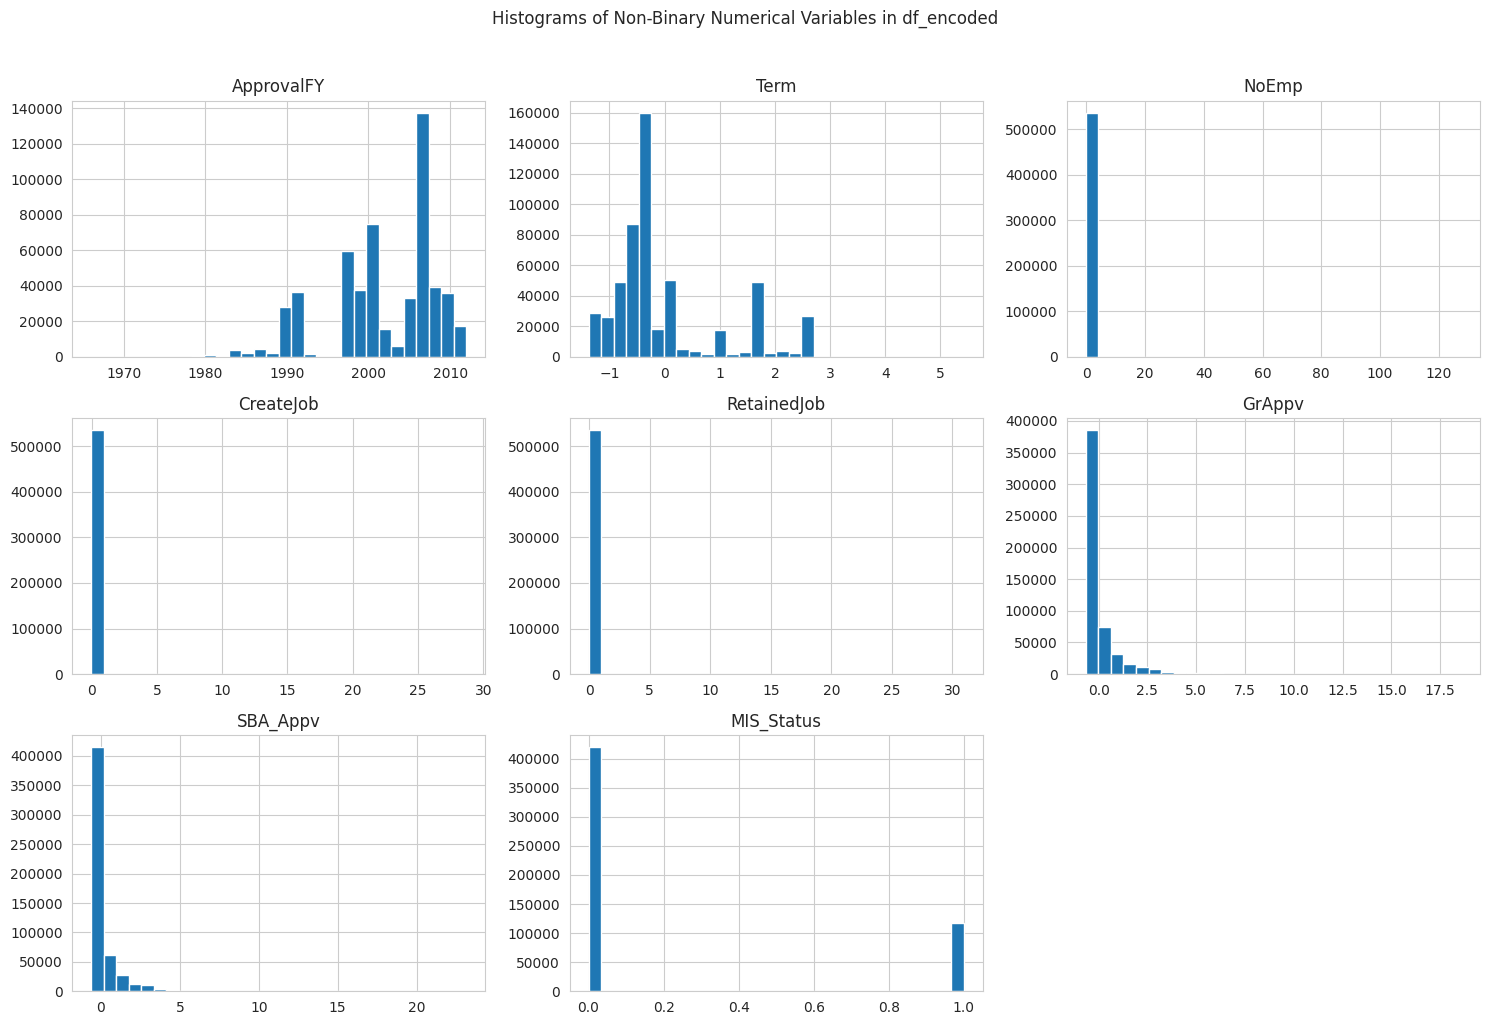

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
# Identify non-binary numerical columns in df_encoded to look at their distributions as well as our target variable to see how balanced or unbalanced our dataset is
non_binary_cols = [
    'ApprovalFY',
    'Term',
    'NoEmp',
    'CreateJob',
    'RetainedJob',
    'GrAppv',
    'SBA_Appv',
    'MIS_Status'
]
df_cleaned[non_binary_cols].hist(figsize=(15, 10), bins=30)
plt.suptitle('Histograms of Non-Binary Numerical Variables in df_encoded', y=1.02)
plt.tight_layout()
plt.show()

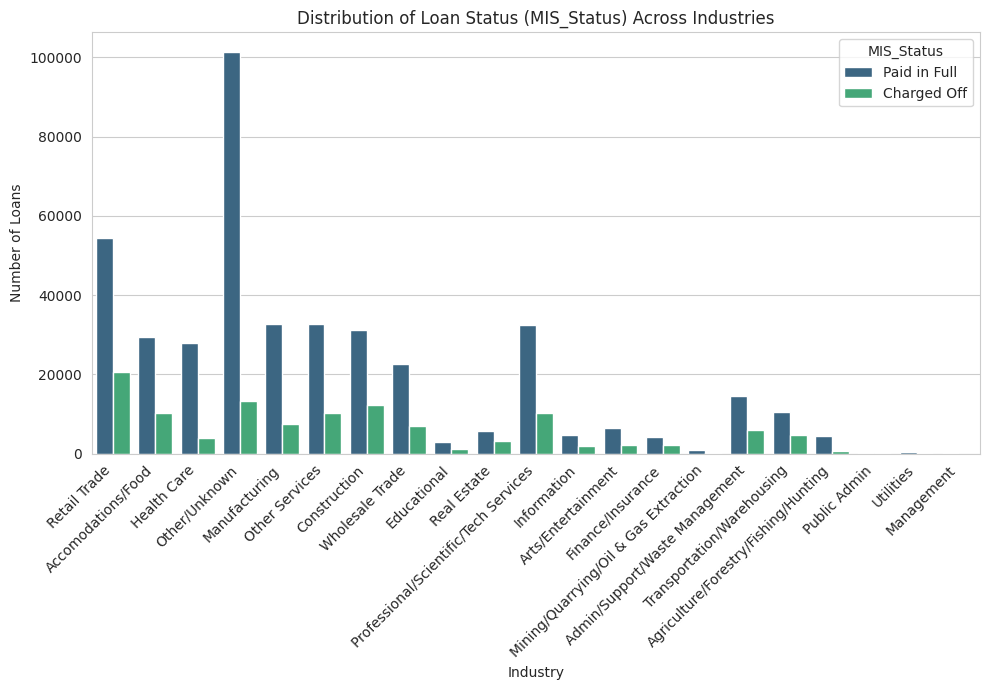

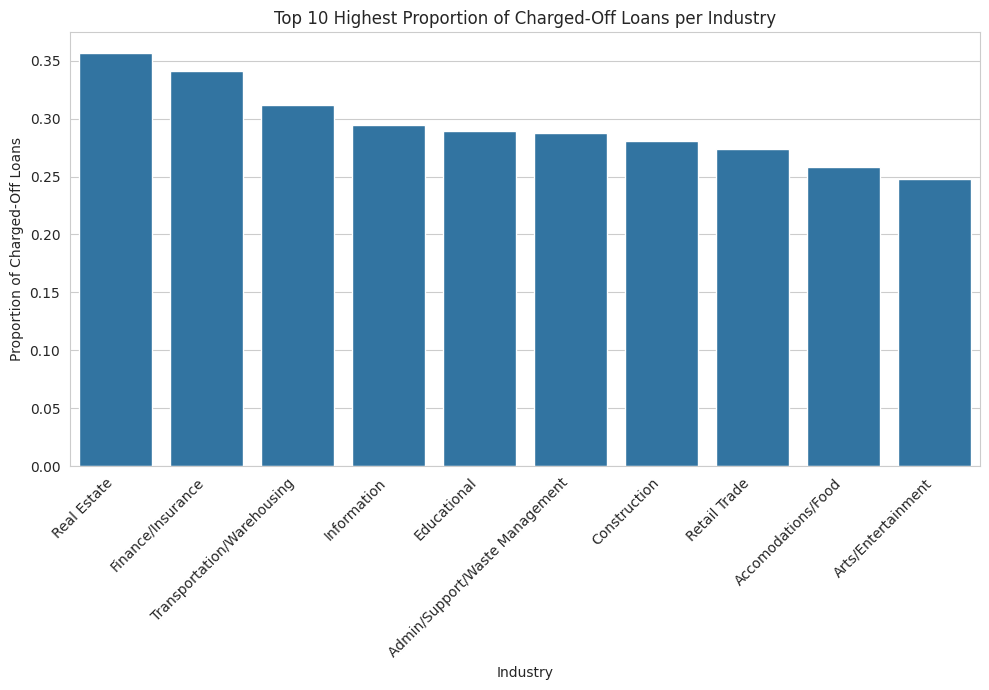

In [ ]:
sns.set_style("whitegrid")
# Plotting the distribution of MIS_Status across industries
plt.figure(figsize=(10, 7))
sns.countplot(data=df, x='Industry', hue='MIS_Status', palette='viridis')
plt.title('Distribution of Loan Status (MIS_Status) Across Industries')
plt.xlabel('Industry')
plt.ylabel('Number of Loans')
plt.xticks(rotation=45, ha='right')
plt.legend(title='MIS_Status', labels=['Paid in Full', 'Charged Off'])
plt.tight_layout()
plt.show()
# Optional: Calculate the proportion of charged-off loans per industry
industry_chargeoff_rate = df.groupby('Industry')['MIS_Status'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 7))
sns.barplot(x=industry_chargeoff_rate.index, y=industry_chargeoff_rate.values, legend=False)
plt.title('Top 10 Highest Proportion of Charged-Off Loans per Industry')
plt.xlabel('Industry')
plt.ylabel('Proportion of Charged-Off Loans')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import plotly.express as px
# Load the reference coordinate dataset
url = "https://raw.githubusercontent.com/plotly/datasets/master/us-cities-top-1k.csv"
city_coords = pd.read_csv(url)
# State Mapping (Standardizing for the merge)
state_map = {
    'AK': 'Alaska', 'AL': 'Alabama', 'AR': 'Arkansas', 'AZ': 'Arizona', 'CA': 'California', 'CO': 'Colorado', 'CT': 'Connecticut',
    'DC': 'District of Columbia', 'DE': 'Delaware', 'FL': 'Florida', 'GA': 'Georgia', 'HI': 'Hawaii', 'IA': 'Iowa', 'ID': 'Idaho',
    'IL': 'Illinois', 'IN': 'Indiana', 'KS': 'Kansas', 'KY': 'Kentucky', 'LA': 'Louisiana', 'MA': 'Massachusetts', 'MD': 'Maryland',
    'ME': 'Maine', 'MI': 'Michigan', 'MN': 'Minnesota', 'MO': 'Missouri', 'MS': 'Mississippi', 'MT': 'Montana', 'NC': 'North Carolina',
    'ND': 'North Dakota', 'NE': 'Nebraska', 'NH': 'New Hampshire', 'NJ': 'New Jersey', 'NM': 'New Mexico', 'NV': 'Nevada',
    'NY': 'New York', 'OH': 'Ohio', 'OK': 'Oklahoma', 'OR': 'Oregon', 'PA': 'Pennsylvania', 'RI': 'Rhode Island', 'SC': 'South Carolina',
    'SD': 'South Dakota', 'TN': 'Tennessee', 'TX': 'Texas', 'UT': 'Utah', 'VA': 'Virginia', 'VT': 'Vermont', 'WA': 'Washington',
    'WI': 'Wisconsin', 'WV': 'West Virginia', 'WY': 'Wyoming'
}
# Clean and Aggregate Data
df['City_Clean'] = df['City'].astype(str).str.title()
df['State_Full'] = df['State'].map(state_map)

city_stats = df.groupby(['City_Clean', 'State_Full']).agg(
    total_loans=('MIS_Status', 'count'),
    charge_off_rate=('MIS_Status', 'mean')
).reset_index()
# Merge with coordinates
map_data = pd.merge(
    city_stats,
    city_coords[['City', 'State', 'lat', 'lon']],
    left_on=['City_Clean', 'State_Full'],
    right_on=['City', 'State'],
    how='inner'
)
# Filter out cities with fewer than 30 loans to stabilize the "Percent Default"
min_volume_threshold = 30
trusted_map_data = map_data[map_data['total_loans'] >= min_volume_threshold]
# Create the Map
fig = px.scatter_geo(
    trusted_map_data.nlargest(500, 'total_loans'), # Increased to 500 cities for better coverage
    lat='lat',
    lon='lon',
    hover_name="City_Clean",
    # Adding total_loans to hover so the user can see the sample size
    hover_data={
        'lat': False,
        'lon': False,
        'total_loans': ':,',
        'charge_off_rate': ':.2%'
    },
    size="total_loans",
    color="charge_off_rate",
    scope="usa",
    template="plotly_white",
    color_continuous_scale="RdYlGn_r", # Red (High Risk) to Green (Low Risk)
    title=f'SBA Loan Risk Map (Cities with >{min_volume_threshold} Loans)',
    labels={'charge_off_rate': 'Default Rate', 'total_loans': 'Volume (Total Loans)'}
)
fig.update_layout(
    margin={"r":0,"t":50,"l":0,"b":0},
    height=700,
    geo=dict(
        landcolor="rgb(240, 240, 240)",
        lakecolor="white",
        showlakes=True
    )
)
fig.show()

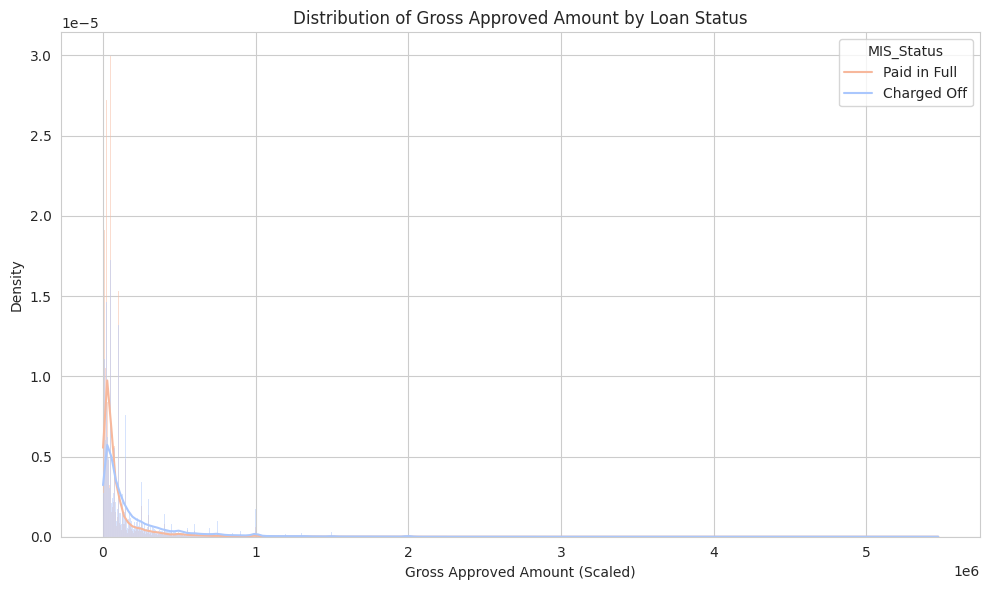

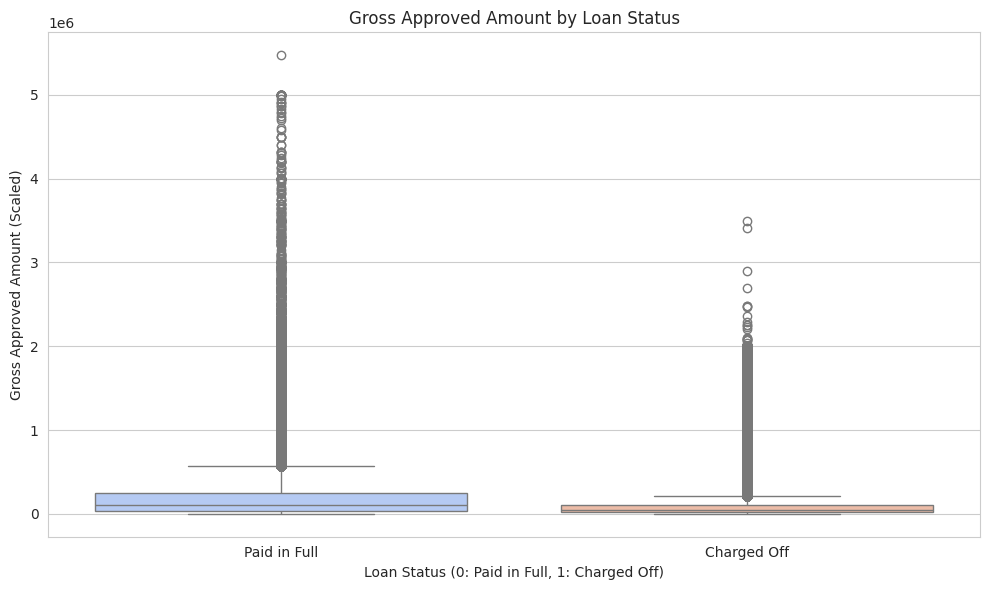

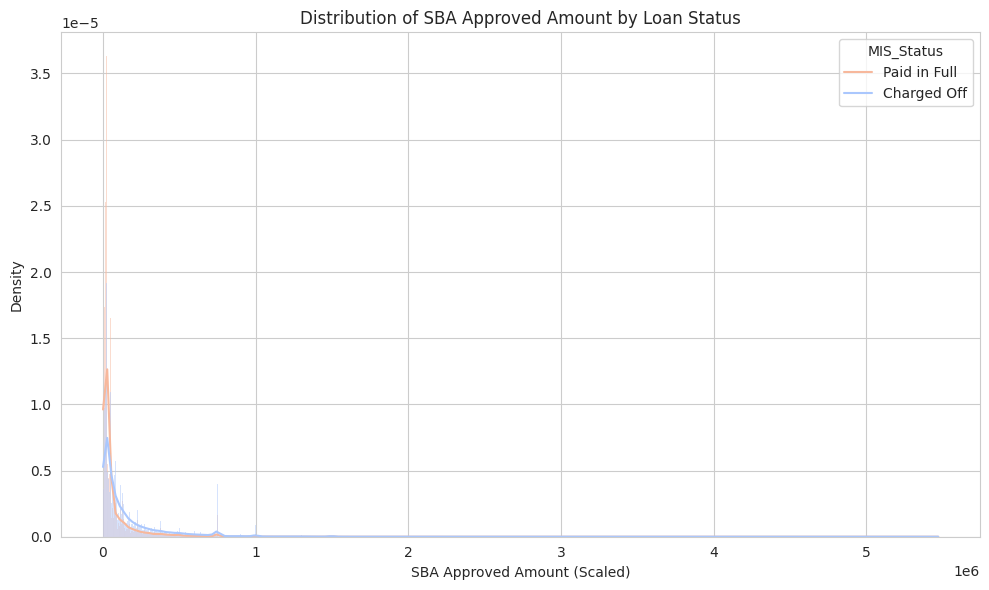

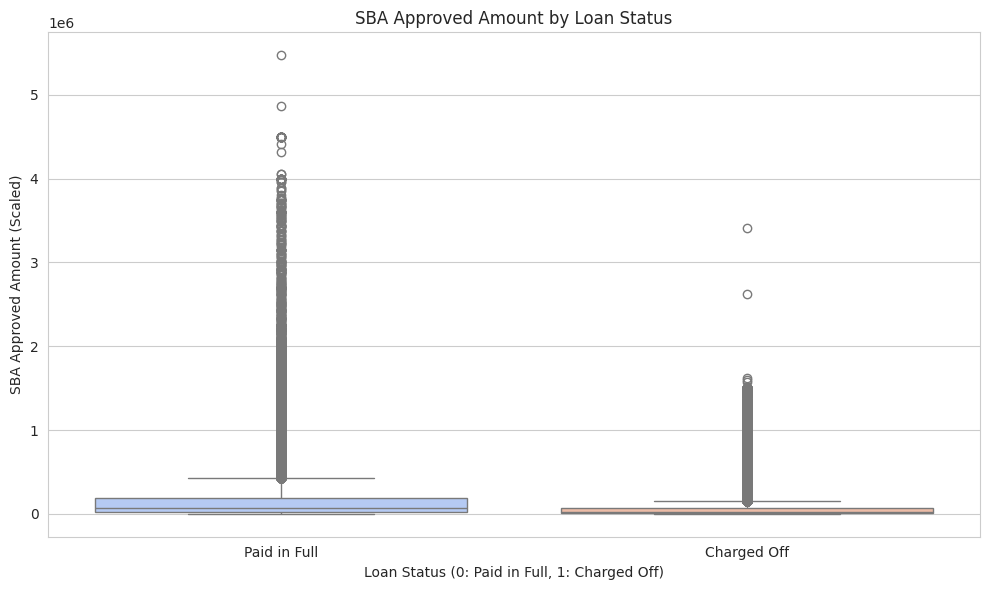

In [ ]:
sns.set_style("whitegrid")
# Distribution of Gross Approved Amount (GrAppv) by MIS_Status
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='GrAppv', hue='MIS_Status', kde=True, palette='coolwarm', stat='density', common_norm=False)
plt.title('Distribution of Gross Approved Amount by Loan Status')
plt.xlabel('Gross Approved Amount (Scaled)')
plt.ylabel('Density')
plt.legend(title='MIS_Status', labels=['Paid in Full', 'Charged Off'])
plt.tight_layout()
plt.show()
# Box plot of Gross Approved Amount (GrAppv) by MIS_Status
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='MIS_Status', y='GrAppv', hue='MIS_Status', palette='coolwarm', legend=False)
plt.title('Gross Approved Amount by Loan Status')
plt.xlabel('Loan Status (0: Paid in Full, 1: Charged Off)')
plt.ylabel('Gross Approved Amount (Scaled)')
plt.xticks([0, 1], ['Paid in Full', 'Charged Off'])
plt.tight_layout()
plt.show()
# Now for SBA_Appv (SBA Approved amount)
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='SBA_Appv', hue='MIS_Status', kde=True, palette='coolwarm', stat='density', common_norm=False)
plt.title('Distribution of SBA Approved Amount by Loan Status')
plt.xlabel('SBA Approved Amount (Scaled)')
plt.ylabel('Density')
plt.legend(title='MIS_Status', labels=['Paid in Full', 'Charged Off'])
plt.tight_layout()
plt.show()
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='MIS_Status', y='SBA_Appv', hue='MIS_Status', palette='coolwarm', legend=False)
plt.title('SBA Approved Amount by Loan Status')
plt.xlabel('Loan Status (0: Paid in Full, 1: Charged Off)')
plt.ylabel('SBA Approved Amount (Scaled)')
plt.xticks([0, 1], ['Paid in Full', 'Charged Off'])
plt.tight_layout()
plt.show()

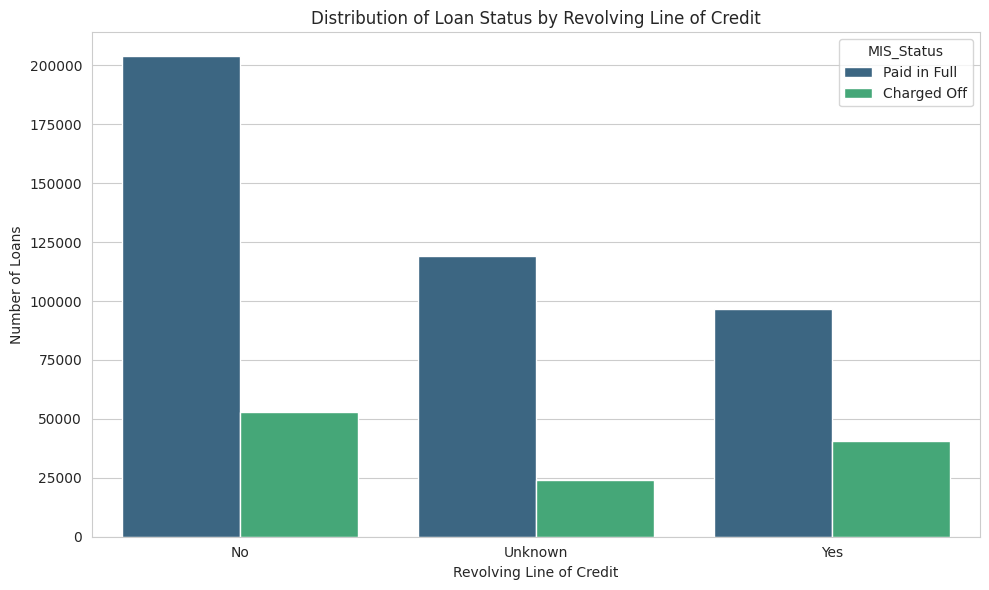

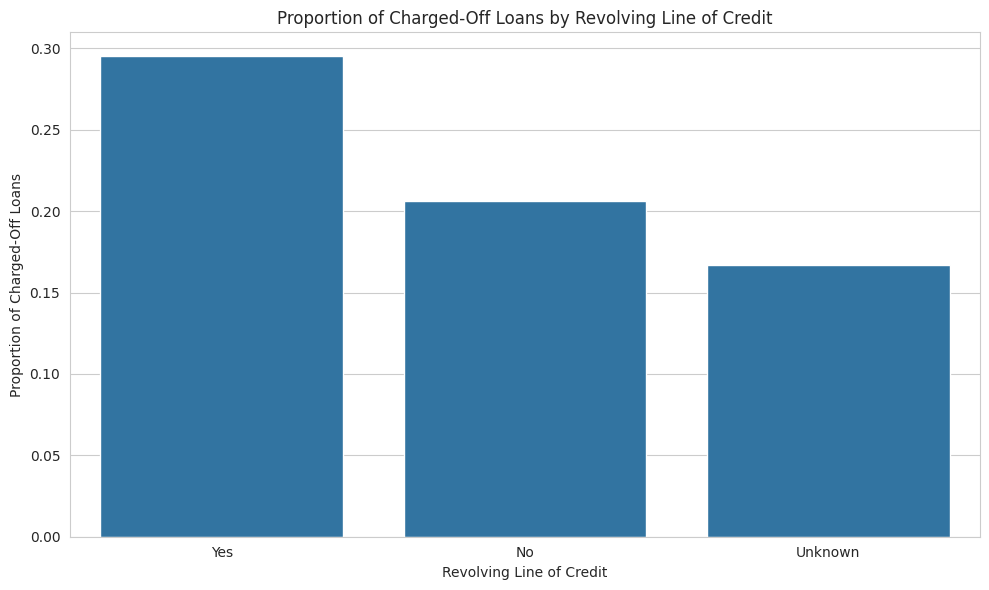

In [ ]:
sns.set_style("whitegrid")
# Plotting the distribution of MIS_Status across RevLineCr categories
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='RevLineCr', hue='MIS_Status', palette='viridis')
plt.title('Distribution of Loan Status by Revolving Line of Credit')
plt.xlabel('Revolving Line of Credit')
plt.ylabel('Number of Loans')
plt.legend(title='MIS_Status', labels=['Paid in Full', 'Charged Off'])
plt.tight_layout()
plt.show()
# Calculate the proportion of charged-off loans per RevLineCr category
revlinecr_chargeoff_rate = df.groupby('RevLineCr')['MIS_Status'].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=revlinecr_chargeoff_rate.index, y=revlinecr_chargeoff_rate.values, legend=False)
plt.title('Proportion of Charged-Off Loans by Revolving Line of Credit')
plt.xlabel('Revolving Line of Credit')
plt.ylabel('Proportion of Charged-Off Loans')
plt.tight_layout()
plt.show()

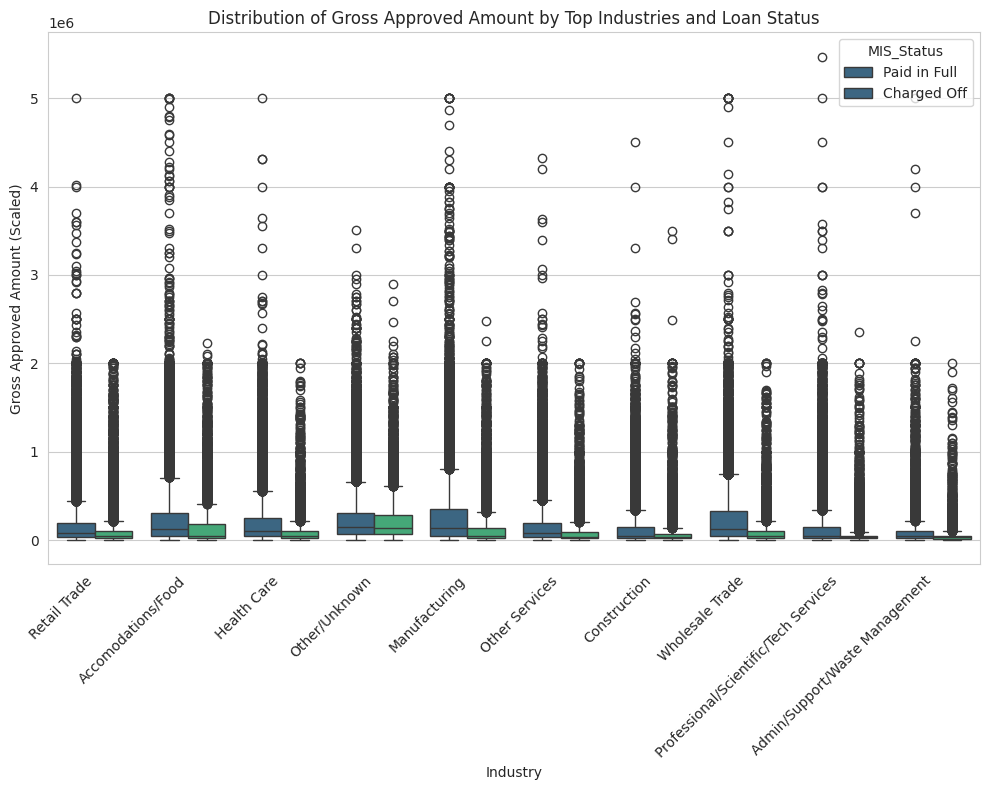

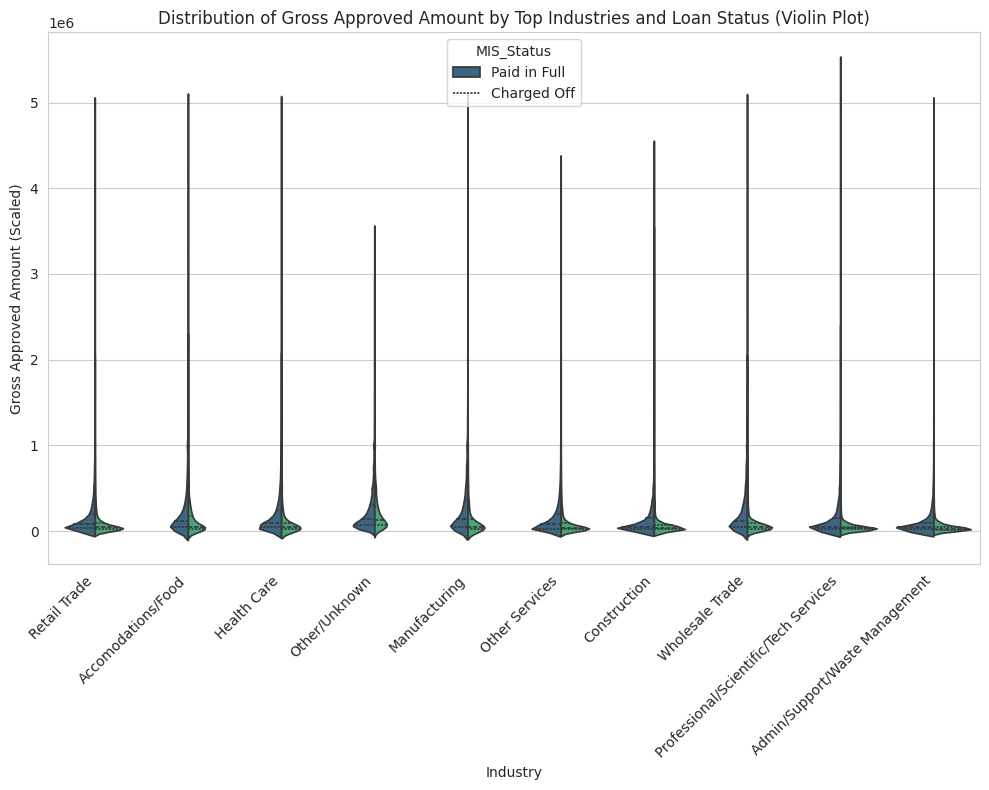

In [ ]:
sns.set_style("whitegrid")
# Select top N industries by count for better visualization
top_n_industries = df['Industry'].value_counts().head(10).index
df_top_industries = df[df['Industry'].isin(top_n_industries)]
# Box plot of Gross Approved Amount (GrAppv) by Industry, with MIS_Status as hue
plt.figure(figsize=(10, 8))
sns.boxplot(data=df_top_industries, x='Industry', y='GrAppv', hue='MIS_Status', palette='viridis')
plt.title('Distribution of Gross Approved Amount by Top Industries and Loan Status')
plt.xlabel('Industry')
plt.ylabel('Gross Approved Amount (Scaled)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='MIS_Status', labels=['Paid in Full', 'Charged Off'])
plt.tight_layout()
plt.show()
# Alternative: Violin plot for a richer view of distribution
plt.figure(figsize=(10, 8))
sns.violinplot(data=df_top_industries, x='Industry', y='GrAppv', hue='MIS_Status', split=True, inner='quart', palette='viridis')
plt.title('Distribution of Gross Approved Amount by Top Industries and Loan Status (Violin Plot)')
plt.xlabel('Industry')
plt.ylabel('Gross Approved Amount (Scaled)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='MIS_Status', labels=['Paid in Full', 'Charged Off'])
plt.tight_layout()
plt.show()

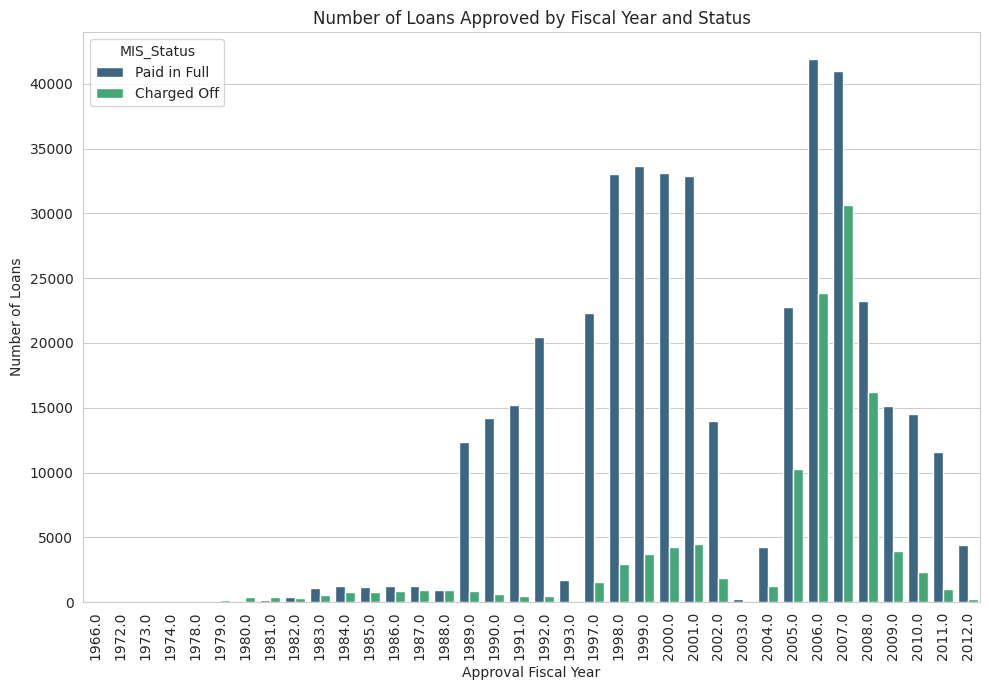

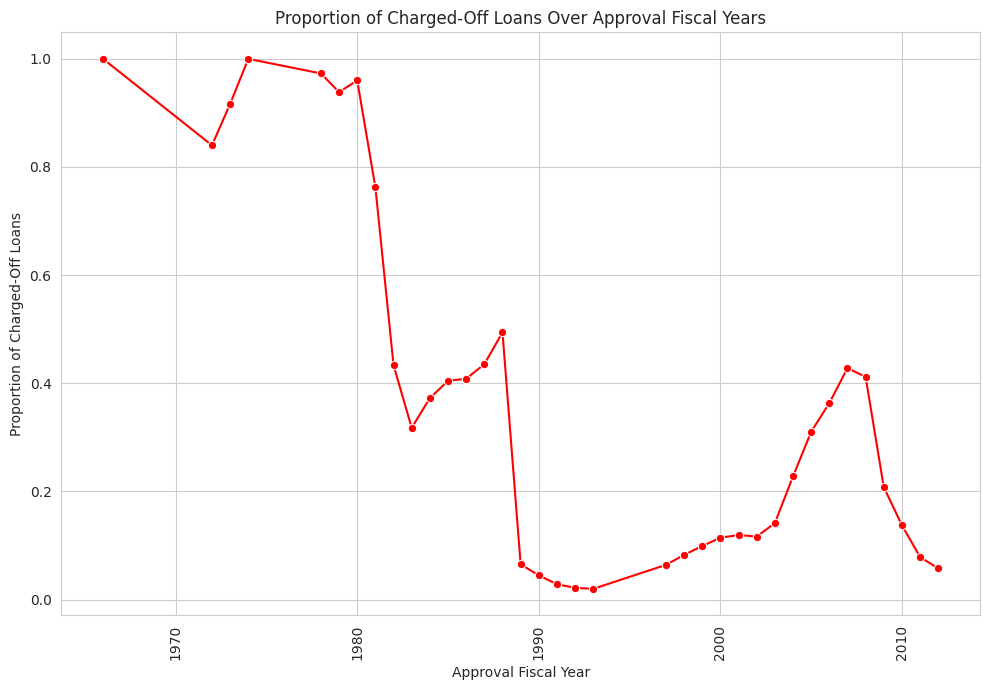

In [ ]:
sns.set_style("whitegrid")
# Plotting the count of loans by ApprovalFY and MIS_Status
plt.figure(figsize=(10, 7))
sns.countplot(data=df, x='ApprovalFY', hue='MIS_Status', palette='viridis')
plt.title('Number of Loans Approved by Fiscal Year and Status')
plt.xlabel('Approval Fiscal Year')
plt.ylabel('Number of Loans')
plt.xticks(rotation=90)
plt.legend(title='MIS_Status', labels=['Paid in Full', 'Charged Off'])
plt.tight_layout()
plt.show()
# Calculate the proportion of charged-off loans per ApprovalFY
fy_chargeoff_rate = df.groupby('ApprovalFY')['MIS_Status'].mean()
plt.figure(figsize=(10, 7))
sns.lineplot(x=fy_chargeoff_rate.index, y=fy_chargeoff_rate.values, marker='o', color='red')
plt.title('Proportion of Charged-Off Loans Over Approval Fiscal Years')
plt.xlabel('Approval Fiscal Year')
plt.ylabel('Proportion of Charged-Off Loans')
plt.xticks(rotation=90)
plt.grid(True)
plt.tight_layout()
plt.show()

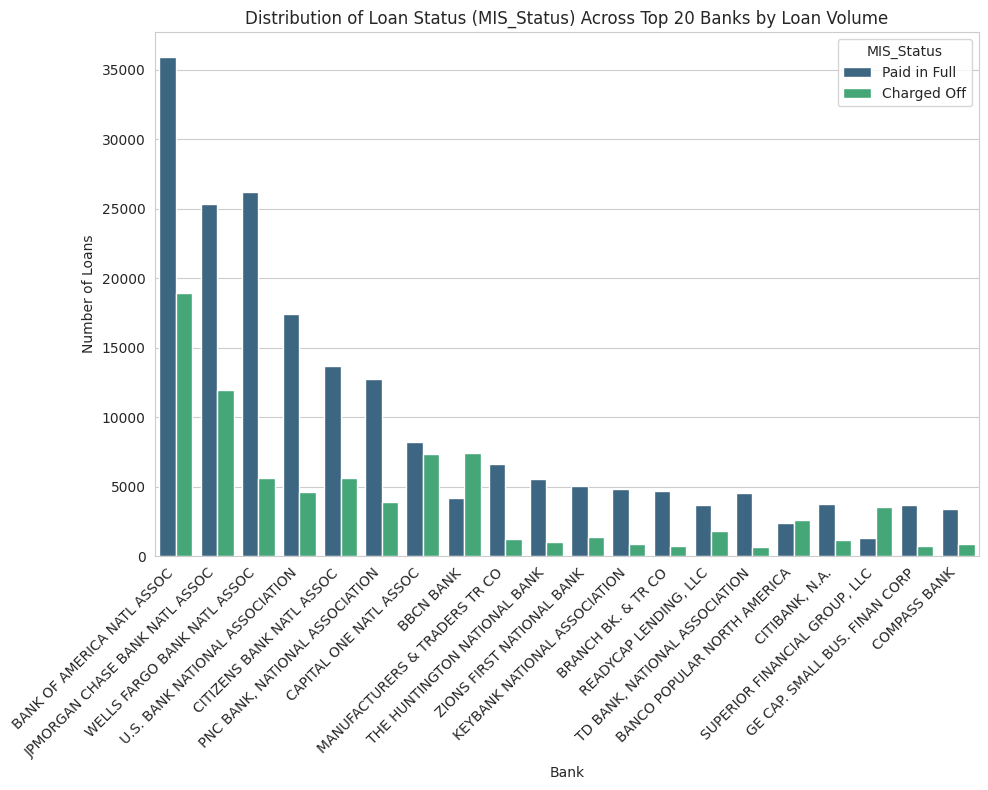

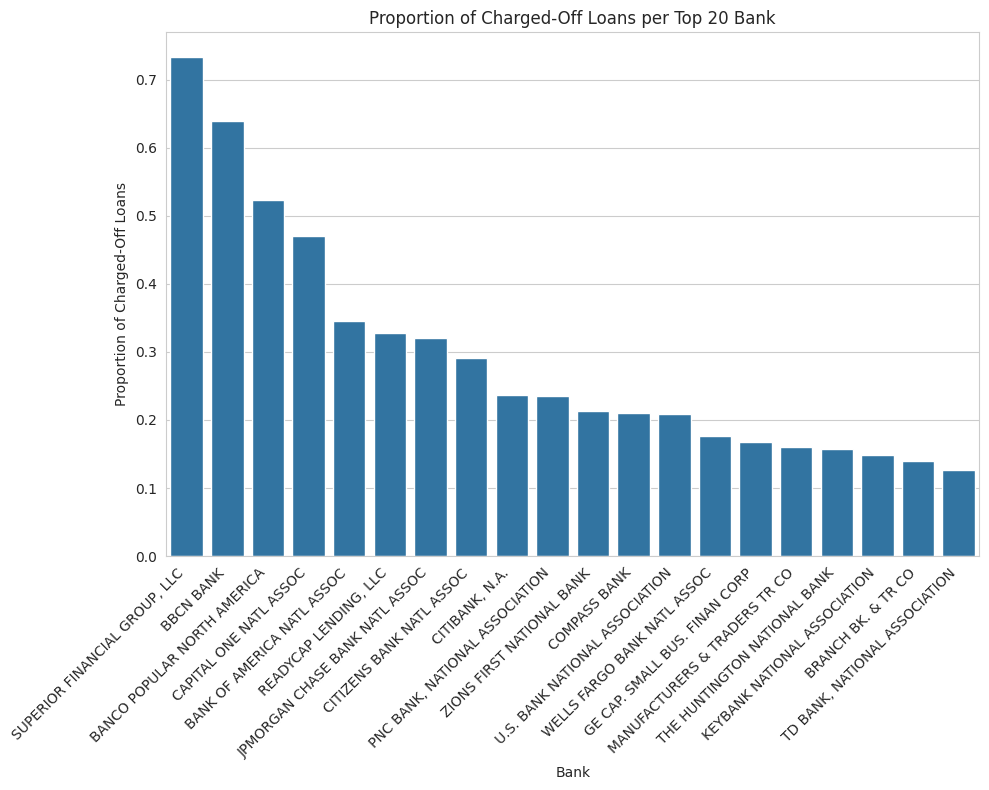

In [ ]:
sns.set_style("whitegrid")
# Calculate loan counts per bank
bank_loan_counts = df['Bank'].value_counts()
# Select the top N banks (e.g., top 20) for better visualization
top_n = 20
top_banks = bank_loan_counts.head(top_n).index
# Filter the DataFrame to include only these top banks
df_top_banks = df[df['Bank'].isin(top_banks)]
# Plotting the distribution of MIS_Status across top banks
plt.figure(figsize=(10, 8))
sns.countplot(data=df_top_banks, x='Bank', hue='MIS_Status', palette='viridis', order=top_banks)
plt.title(f'Distribution of Loan Status (MIS_Status) Across Top {top_n} Banks by Loan Volume')
plt.xlabel('Bank')
plt.ylabel('Number of Loans')
plt.xticks(rotation=45, ha='right')
plt.legend(title='MIS_Status', labels=['Paid in Full', 'Charged Off'])
plt.tight_layout()
plt.show()
# Calculate the proportion of charged-off loans for these top banks
bank_chargeoff_rate = df_top_banks.groupby('Bank')['MIS_Status'].mean().loc[top_banks].sort_values(ascending=False)
plt.figure(figsize=(10, 8))
sns.barplot(x=bank_chargeoff_rate.index, y=bank_chargeoff_rate.values, legend=False)
plt.title(f'Proportion of Charged-Off Loans per Top {top_n} Bank')
plt.xlabel('Bank')
plt.ylabel('Proportion of Charged-Off Loans')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

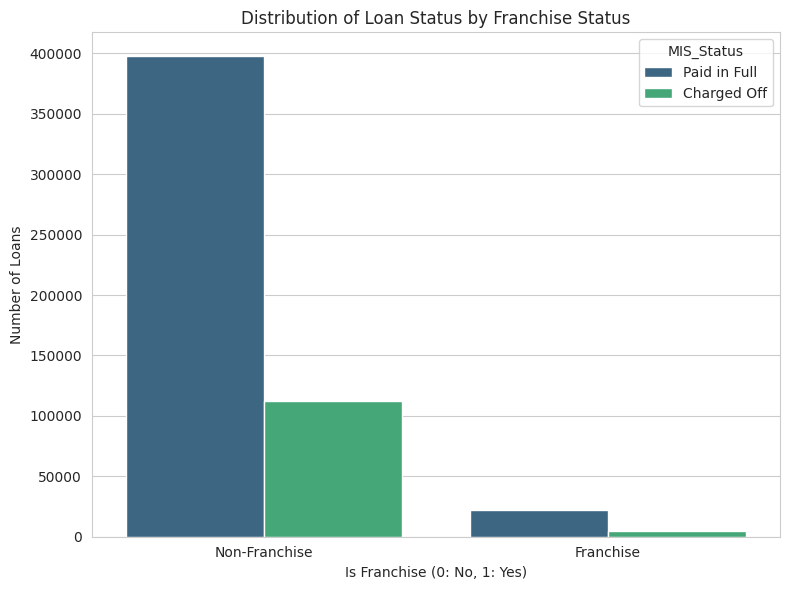

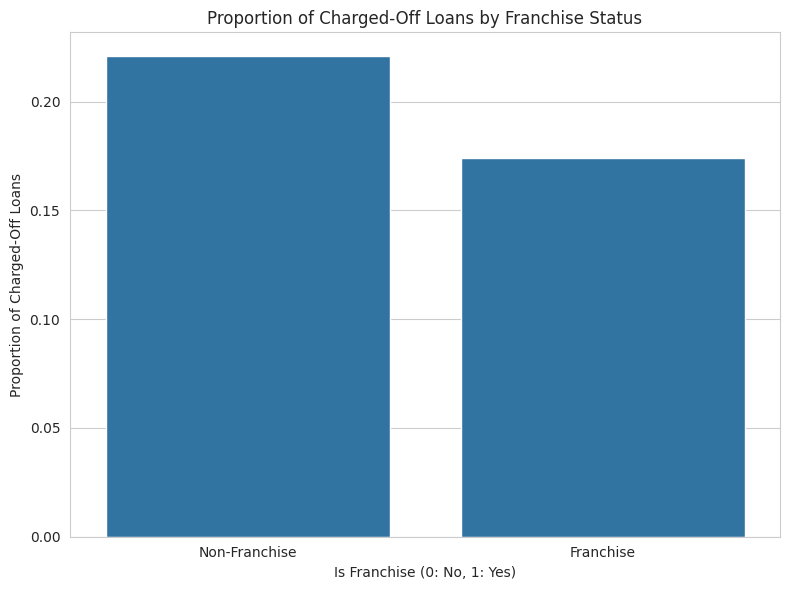

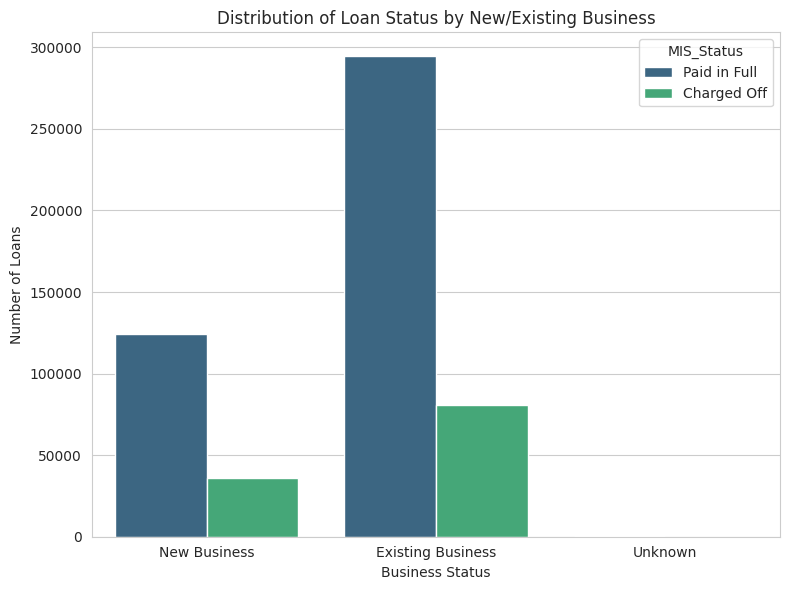

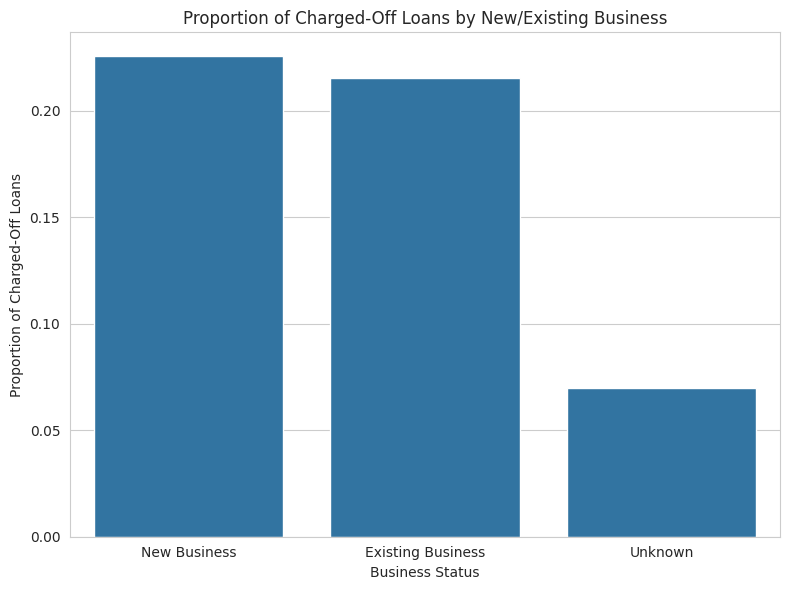

In [ ]:
sns.set_style("whitegrid")
# --- EDA for IsFranchise vs MIS_Status ---
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='IsFranchise', hue='MIS_Status', palette='viridis')
plt.title('Distribution of Loan Status by Franchise Status')
plt.xlabel('Is Franchise (0: No, 1: Yes)')
plt.ylabel('Number of Loans')
plt.xticks([0, 1], ['Non-Franchise', 'Franchise'])
plt.legend(title='MIS_Status', labels=['Paid in Full', 'Charged Off'])
plt.tight_layout()
plt.show()
franchise_chargeoff_rate = df.groupby('IsFranchise')['MIS_Status'].mean().sort_values(ascending=False)
plt.figure(figsize=(8, 6))
sns.barplot(x=franchise_chargeoff_rate.index, y=franchise_chargeoff_rate.values, legend=False)
plt.title('Proportion of Charged-Off Loans by Franchise Status')
plt.xlabel('Is Franchise (0: No, 1: Yes)')
plt.ylabel('Proportion of Charged-Off Loans')
plt.xticks([0, 1], ['Non-Franchise', 'Franchise'])
plt.tight_layout()
plt.show()
# --- EDA for NewExist vs MIS_Status ---
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='NewExist', hue='MIS_Status', palette='viridis')
plt.title('Distribution of Loan Status by New/Existing Business')
plt.xlabel('Business Status')
plt.ylabel('Number of Loans')
plt.legend(title='MIS_Status', labels=['Paid in Full', 'Charged Off'])
plt.tight_layout()
plt.show()
newexist_chargeoff_rate = df.groupby('NewExist')['MIS_Status'].mean().sort_values(ascending=False)
plt.figure(figsize=(8, 6))
sns.barplot(x=newexist_chargeoff_rate.index, y=newexist_chargeoff_rate.values, legend=False)
plt.title('Proportion of Charged-Off Loans by New/Existing Business')
plt.xlabel('Business Status')
plt.ylabel('Proportion of Charged-Off Loans')
plt.tight_layout()
plt.show()

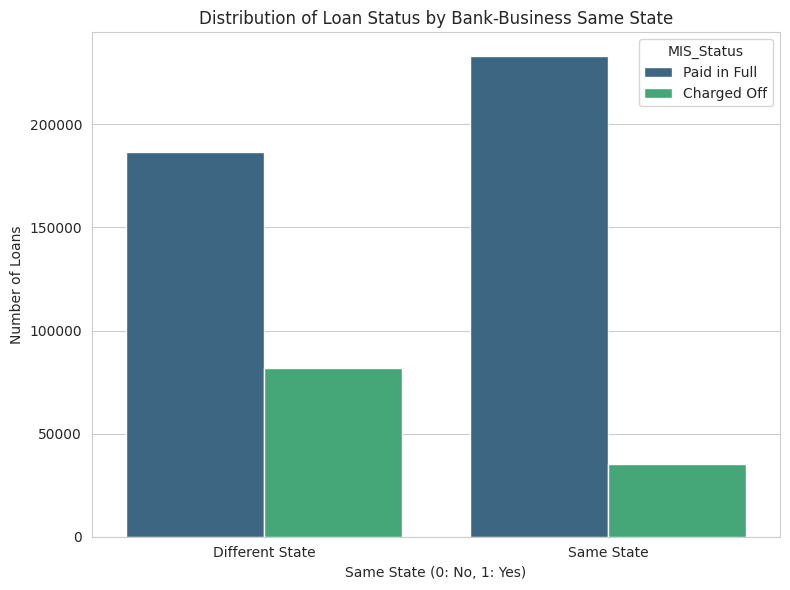

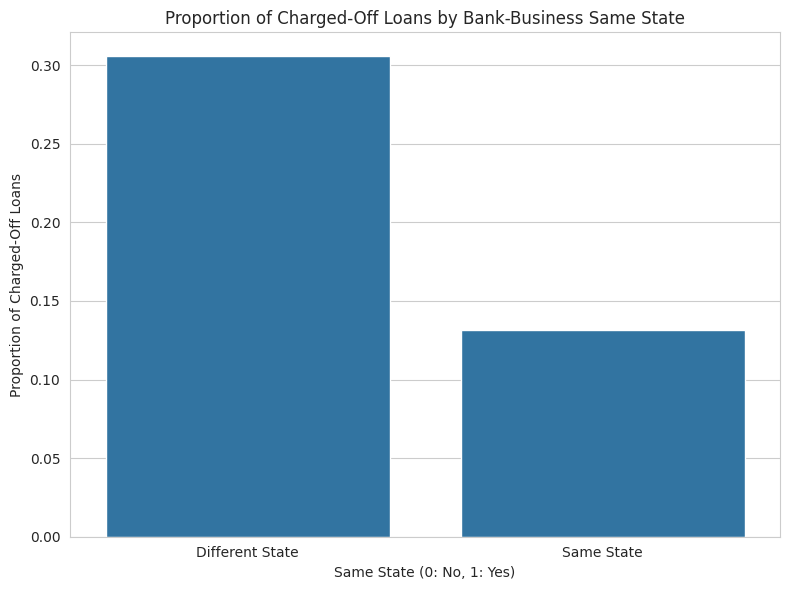

In [ ]:
sns.set_style("whitegrid")
# Create a new feature: Is the bank in the same state as the business?
df['SameState'] = (df['State'] == df['BankState']).astype(int)
# Plotting the distribution of MIS_Status by SameState
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='SameState', hue='MIS_Status', palette='viridis')
plt.title('Distribution of Loan Status by Bank-Business Same State')
plt.xlabel('Same State (0: No, 1: Yes)')
plt.ylabel('Number of Loans')
plt.xticks([0, 1], ['Different State', 'Same State'])
plt.legend(title='MIS_Status', labels=['Paid in Full', 'Charged Off'])
plt.tight_layout()
plt.show()
# Calculate the proportion of charged-off loans by SameState
same_state_chargeoff_rate = df.groupby('SameState')['MIS_Status'].mean().sort_values(ascending=False)
plt.figure(figsize=(8, 6))
sns.barplot(x=same_state_chargeoff_rate.index, y=same_state_chargeoff_rate.values, legend=False)
plt.title('Proportion of Charged-Off Loans by Bank-Business Same State')
plt.xlabel('Same State (0: No, 1: Yes)')
plt.ylabel('Proportion of Charged-Off Loans')
plt.xticks([0, 1], ['Different State', 'Same State'])
plt.tight_layout()
plt.show()